In [8]:
import pickle
import numpy as np
import pandas as np
import seaborn as sns
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))
import surr_model.functions.plots as pf

In [7]:
import matplotlib.pyplot as plt


def plot_losses(train_losses, val_losses, title="Training and Validation Loss"):
    """
    Plots training and validation loss curves.

    Parameters
    ----------
    train_losses : list or array
        Loss values recorded on the training set.
    val_losses : list or array
        Loss values recorded on the validation set.
    title : str
        Title of the plot.
    """
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


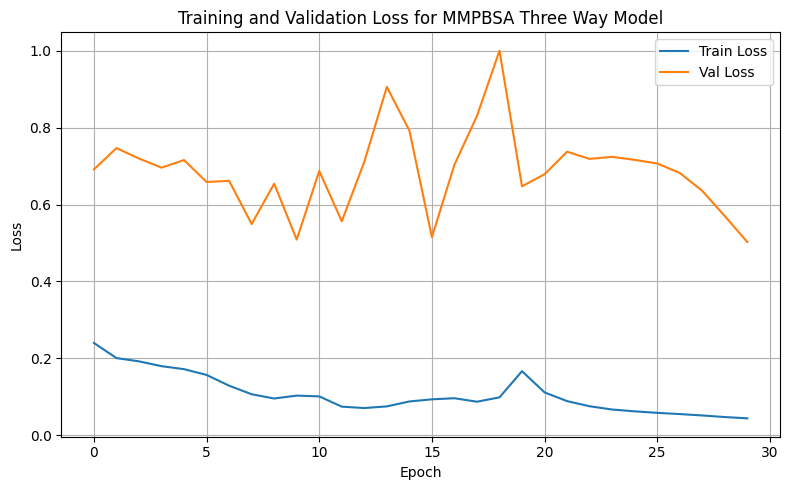

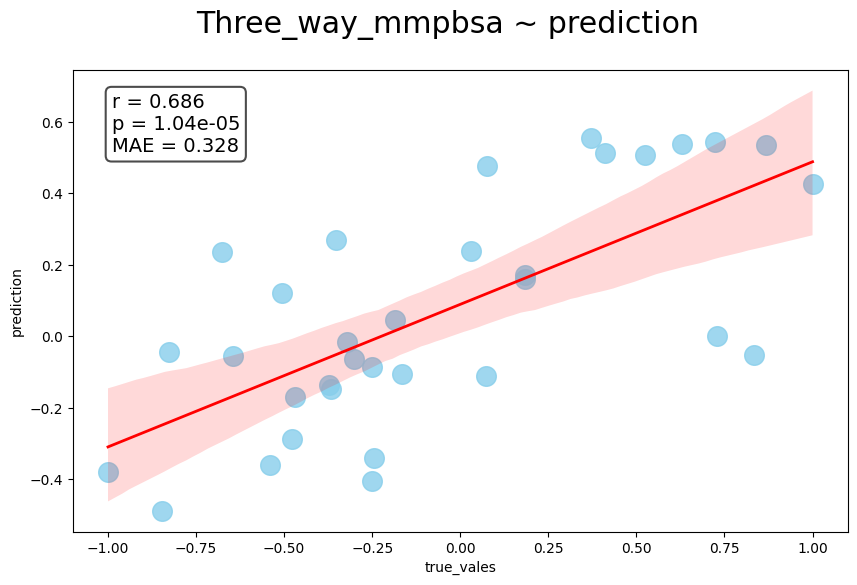

In [3]:
with open(
    "/home/kunzj/BindCraft_uva_internship/surr_model/training_results_jax/results_mmpbsa_three_way.pkl",
    "rb",
) as f:
    data = pickle.load(f)
plot_losses(
    data["train_losses"],
    data["val_losses"],
    title="Training and Validation Loss for MMPBSA Three Way Model",
)
pf.linear_corr_plot(
    value_x=data["y_val_list"],
    value_y=data["pred_y_list"],
    x_label="true_vales",
    y_label="prediction",
    title="Three_way_mmpbsa ~ prediction",
)


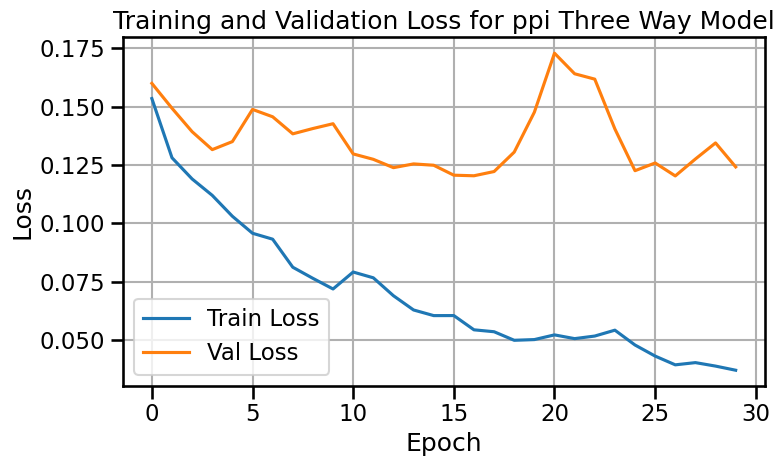

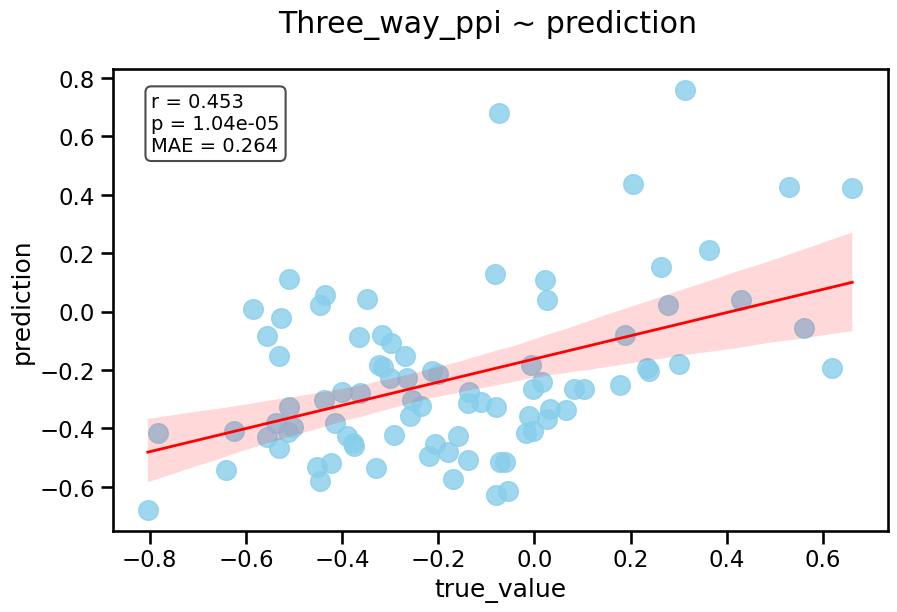

In [4]:
with open(
    "/home/kunzj/BindCraft_uva_internship/surr_model/training_results_jax/results_ppi_three_way.pkl",
    "rb",
) as f:
    data = pickle.load(f)
plot_losses(
    data["train_losses"],
    data["val_losses"],
    title="Training and Validation Loss for ppi Three Way Model",
)
pf.linear_corr_plot(
    value_x=data["y_val_list"],
    value_y=data["pred_y_list"],
    x_label="true_value",
    y_label="prediction",
    title="Three_way_ppi ~ prediction",
)


In [5]:
min(data["y_val_list"])

-0.8042103052139282

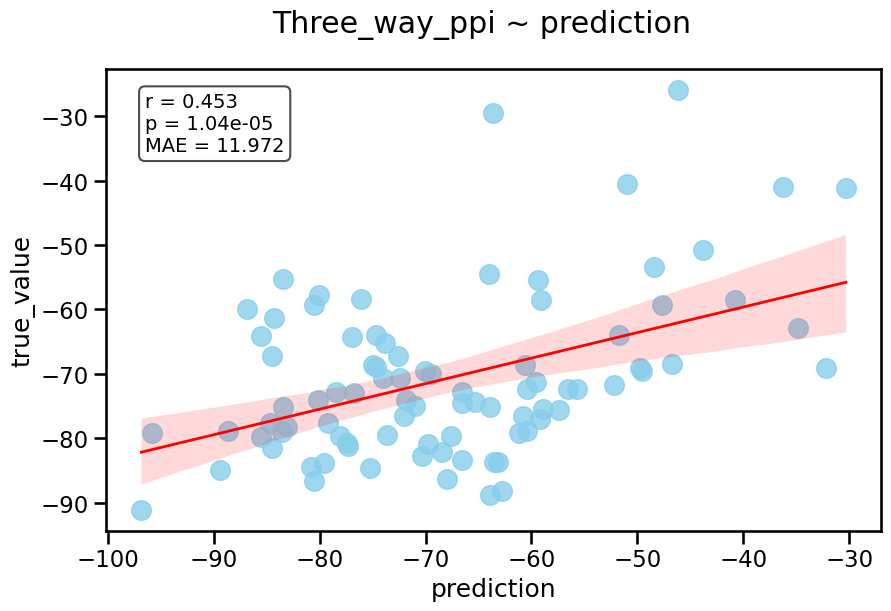

In [6]:
pf.linear_corr_plot_true_val(
    value_x=data["y_val_list"],
    value_y=data["pred_y_list"],
    x_label="prediction",
    y_label="true_value",
    title="Three_way_ppi ~ prediction",
)

In [1]:
print(f"MAE in KCal/mol: {11.972 / 4.184}")

MAE in KCal/mol: 2.861376673040153


### last model ppi comparison to torch

In [2]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))
import equinox as eqx
import esm  # pip install fair-esm==2.0.0
import esm2quinox
import jax.random as jrandom
import optax  # pip install optax
from surr_model.dataset.dataset import Dataset_PEPBI
from surr_model.functions.model import (
    stripped_PREDICTOR,
)
from surr_model.functions.training import (
    eval_step,
    train_model_validation,
)
import jax.numpy as jnp
import jax.random as jr
import jax
from torch.utils.data import DataLoader
import pickle

In [3]:
data_ppi_test_three_split = Dataset_PEPBI(
    columns=["Prot_Seq", "Pept_Seq", "Energy"],
    data_path="/home/kunzj/BindCraft_uva_internship/data/ppi_affinity_dataset/cosine_sim_scaled/three_way/test.csv",
    transform=esm2quinox.tokenise,
)

loader_ppi_test_three_split = DataLoader(data_ppi_test_three_split, batch_size=1)


In [5]:
model_key, call_key = jr.split(jr.PRNGKey(0), 2)

# initializing models
torch_model, _ = esm.pretrained.esm2_t30_150M_UR50D()
model_esm2 = esm2quinox.from_torch(torch_model)

model_aff = stripped_PREDICTOR(
    model= model_esm2, key=model_key
)

best_model = eqx.tree_deserialise_leaves('/home/kunzj/BindCraft_uva_internship/surr_model/training_results_jax/model_ppi_last_epoch.eqx',model_aff)
test_key_init = jr.PRNGKey(1)
inference_model = eqx.nn.inference_mode(best_model)

test_loss_list = []
pred_y_list = []
y_val_list = []

for entry, (x_prot, x_pept, y_val) in enumerate(loader_ppi_test_three_split):
    x_prot, x_pept, y_val = jnp.array(x_prot), jnp.array(x_pept), jnp.array(y_val)
    test_key = jr.split(test_key_init, x_pept.shape[0])
    test_loss, pred_y = eval_step(inference_model, x_prot, x_pept, y_val, test_key)
    test_loss_list.append(test_loss.item())
    pred_y_list.append(pred_y.item())
    y_val_list.append(y_val.item())
    print(
        f"[Entry {entry + 1}] , Test Loss: {test_loss:.3f}, Predicted Y: {pred_y.item():.3f}, , True Y: {y_val.item():.3f}"
    )

results_ppi_three_way = {
    "test_loss_list": test_loss_list,
    "pred_y_list": pred_y_list,
    "y_val_list": y_val_list,
}

2025-12-16 22:20:35.208594: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2025-12-16 22:20:35.209080: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.


[Entry 1] , Test Loss: 0.005, Predicted Y: -0.386, , True Y: -0.315
[Entry 2] , Test Loss: 0.030, Predicted Y: -0.467, , True Y: -0.641
[Entry 3] , Test Loss: 0.003, Predicted Y: -0.510, , True Y: -0.452
[Entry 4] , Test Loss: 0.042, Predicted Y: -0.424, , True Y: -0.220
[Entry 5] , Test Loss: 0.062, Predicted Y: -0.456, , True Y: -0.207
[Entry 6] , Test Loss: 0.015, Predicted Y: -0.378, , True Y: -0.254
[Entry 7] , Test Loss: 0.105, Predicted Y: -0.086, , True Y: 0.237
[Entry 8] , Test Loss: 0.241, Predicted Y: -0.571, , True Y: -0.080
[Entry 9] , Test Loss: 0.294, Predicted Y: -0.043, , True Y: -0.585
[Entry 10] , Test Loss: 0.155, Predicted Y: -0.412, , True Y: -0.018
[Entry 11] , Test Loss: 0.022, Predicted Y: -0.259, , True Y: -0.111
[Entry 12] , Test Loss: 0.000, Predicted Y: -0.436, , True Y: -0.438
[Entry 13] , Test Loss: 0.051, Predicted Y: -0.283, , True Y: -0.510
[Entry 14] , Test Loss: 0.117, Predicted Y: -0.165, , True Y: 0.178
[Entry 15] , Test Loss: 0.257, Predicted Y: -

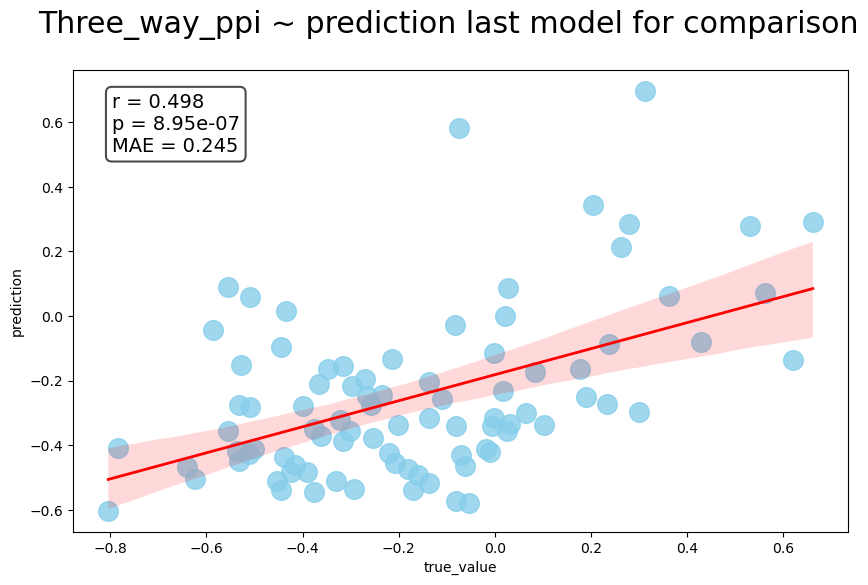

In [9]:
pf.linear_corr_plot(
    value_x=results_ppi_three_way["y_val_list"],
    value_y=results_ppi_three_way["pred_y_list"],
    x_label="true_value",
    y_label="prediction",
    title="Three_way_ppi ~ prediction last model for comparison",
)

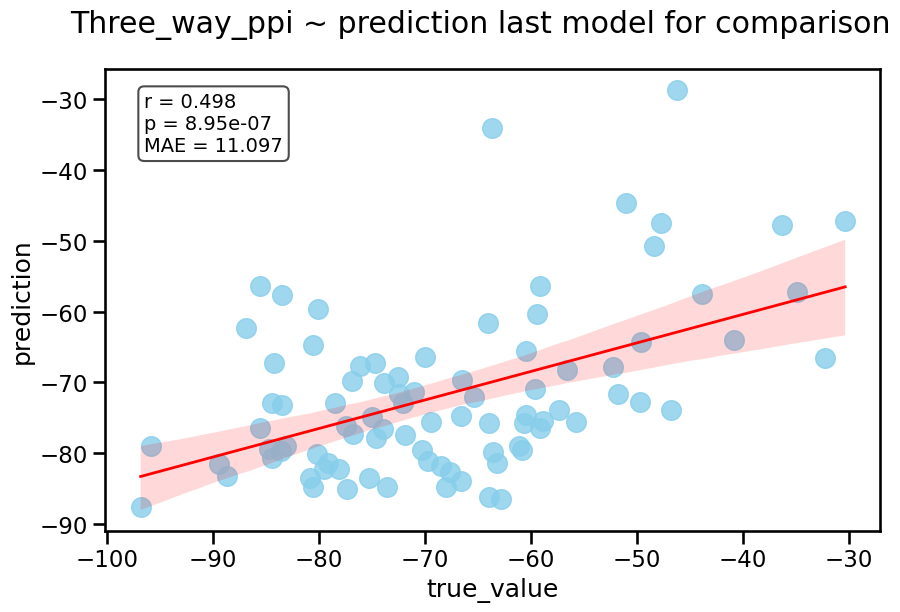

In [11]:
pf.linear_corr_plot_true_val(
    value_x=results_ppi_three_way["y_val_list"],
    value_y=results_ppi_three_way["pred_y_list"],
    x_label="true_value",
    y_label="prediction",
    title="Three_way_ppi ~ prediction last model for comparison",
)

In [ ]:
print(f"MAE in KCal/mol: {11.097 / 4.184}")

MAE in KCal/mol: 2.652246653919694


: 

### other training

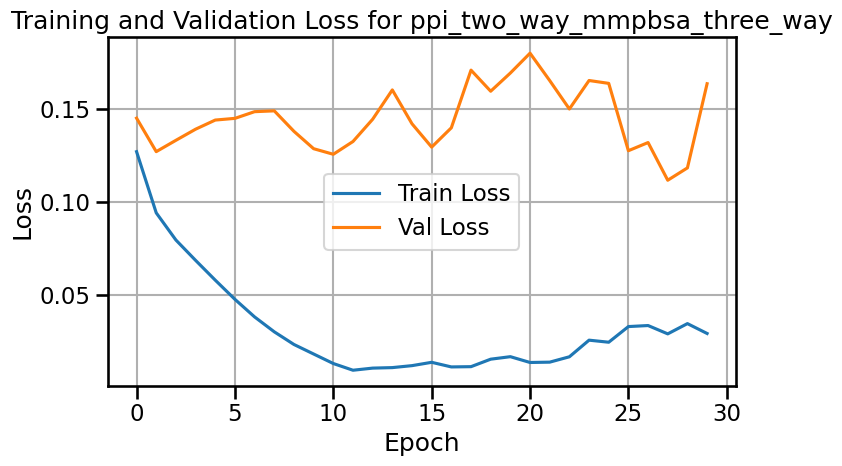

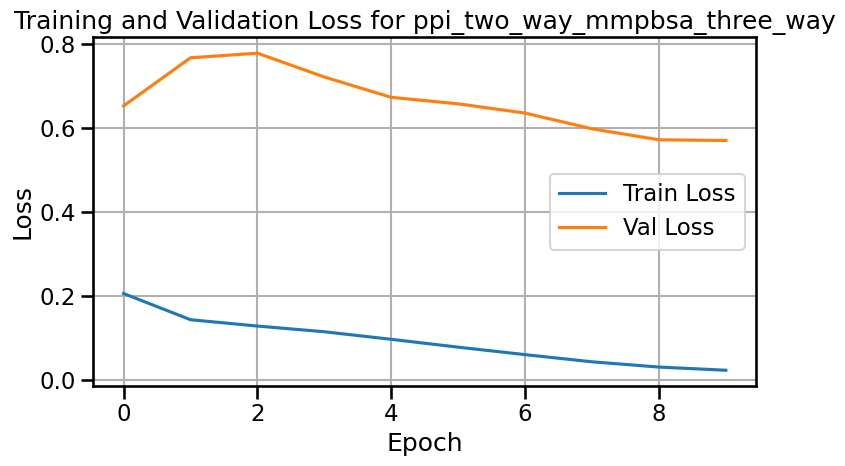

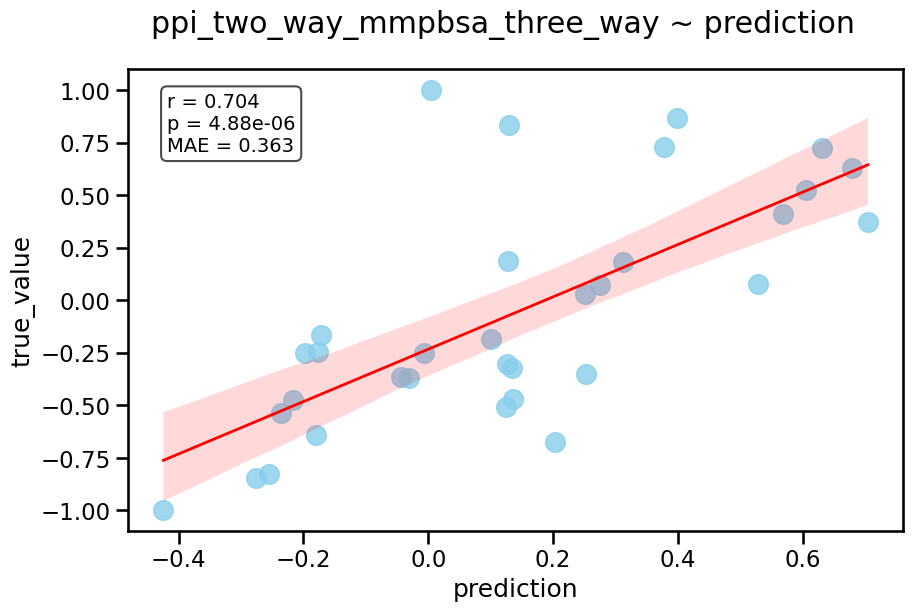

In [ ]:
analysis_name = "ppi_two_way_mmpbsa_three_way"
with open(
    f"/home/kunzj/BindCraft_uva_internship/surr_model/training_results_jax/results_{analysis_name}.pkl",
    "rb",
) as f:
    data = pickle.load(f)
plot_losses(
    data["train_losses_first"],
    data["val_losses_first"],
    title=f"Training and Validation Loss for {analysis_name}",
)
plot_losses(
    data["train_losses_second"],
    data["val_losses_second"],
    title=f"Training and Validation Loss for {analysis_name}",
)
pf.linear_corr_plot(
    value_x=data["pred_y_list"],
    value_y=data["y_val_list"],
    x_label="prediction",
    y_label="true_value",
    title=f"{analysis_name} ~ prediction",
)